In [3]:
import sys
import os
from pathlib import Path

# --- 1. ENVIRONMENT DETECTION ---
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("☁️ [Axiom Cloud] Running on Google Colab.")
    print("📦 Installing Axiom dependencies...")
    # Using -q for quiet install
    !pip install -q pandas numpy scikit-learn matplotlib seaborn
    
    # Clone repo to access /src and /data if needed
    REPO_URL = "https://github.com/shailoh-a11y/axiom_mlops_project.git"
    REPO_NAME = "axiom_mlops_project"
    if not os.path.exists(REPO_NAME):
        !git clone {REPO_URL}
    
    os.chdir(REPO_NAME)
    # Ensure the cloned repo is in the path
    if os.getcwd() not in sys.path:
        sys.path.append(os.getcwd())
else:
    print("💻 [Axiom Local] Running in Antigravity (.venv).")
    
    # --- AXIOM HOME BASE LOGIC (LOCAL) ---
    # If we are inside the 'notebooks' folder, we need to move up to the root
    # so we can see 'src' and 'data'
    current_path = Path(os.getcwd())
    if current_path.name == "notebooks":
        os.chdir("..")
        print("🏠 Moved up to Project Root.")
    
    # Add the root directory to sys.path so 'import src' works
    root_path = os.getcwd()
    if root_path not in sys.path:
        sys.path.append(root_path)

print(f"📂 Current Working Directory: {os.getcwd()}")
print(f"✅ Visible Folders: {os.listdir()}")

💻 [Axiom Local] Running in Antigravity (.venv).
🏠 Moved up to Project Root.
📂 Current Working Directory: /Users/ellenpeterson/Desktop/axiom_mlops_project
✅ Visible Folders: ['uv.lock', '.ruff_cache', 'pyproject.toml', 'tests', 'README.md', '.gitignore', 'configs', '.venv', '.python-version', '.git', '.vscode', 'data', 'notebooks', 'src']


In [4]:
# --- TIER 1: Standard Library ---
import os
import sys
from pathlib import Path

# --- TIER 2: Third-Party Stack ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split

# --- TIER 3: Local Axiom Code ---
try:
    # This now works because we fixed the path in the first cell!
    import src.main as axiom_main
    print("✅ Local 'src' modules linked.")
except ImportError:
    print("⚠️ Warning: 'src' folder not found in path.")

print("📚 Libraries Loaded.")

✅ Local 'src' modules linked.
📚 Libraries Loaded.


In [5]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- 1. PATH SETTINGS ---
ROOT = Path(os.getcwd())
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"

# Ensure directories exist
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# --- 2. DATASET SETTINGS (Axiom Specifics) ---
# We use the name you gave the file in the data/ folder
FILE_NAME = "funding_data.csv" 

# We set the target to the status column you want to predict
TARGET_COL = "fund_order_status"

# We define the main feature we are testing for the prototype
FEATURES = ["fund_type", "fund_amount"] 

# --- 3. GLOBAL HYPERPARAMETERS ---
RANDOM_STATE = 42
TEST_SIZE = 0.2
SHUFFLE = True

# --- 4. UI/UX OPTIONS (The "Axiom" View) ---
pd.options.display.max_columns = None
pd.options.display.precision = 2
# Force Scikit-Learn to output DataFrames instead of messy Arrays
sklearn.set_config(transform_output="pandas")
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")

print(f"⚙️ Axiom Configs locked for: {FILE_NAME}")
print(f"🎯 Target: {TARGET_COL} | 🛠 Features: {FEATURES}")

⚙️ Axiom Configs locked for: funding_data.csv
🎯 Target: fund_order_status | 🛠 Features: ['fund_type', 'fund_amount']


In [6]:
# --- DATA LOADING ---
DATA_PATH = DATA_DIR / FILE_NAME

if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
    print(f"✅ Success! Loaded {FILE_NAME}")
    
    # --- 1. QUICK INSPECTION ---
    print(f"📊 Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")
    display(df.head())
    
    # --- 2. DATA TYPES & MISSING VALUES ---
    print("\n🔍 Data Health Summary:")
    health_check = pd.DataFrame({
        'Data Type': df.dtypes,
        'Missing Values': df.isnull().sum(),
        'Unique Values': df.nunique()
    })
    display(health_check)

    # --- 3. TARGET VALUE CHECK ---
    print(f"\n🎯 Target Breakdown ({TARGET_COL}):")
    print(df[TARGET_COL].value_counts())

else:
    print(f"❌ Error: Could not find '{FILE_NAME}' in {DATA_DIR}")
    print(f"Verify the file is in: {DATA_DIR.absolute()}")

✅ Success! Loaded funding_data.csv
📊 Dataset Shape: 2574563 rows x 5 columns


,actor_role_id,created_time,fund_type,fund_amount,fund_order_status
0,216610000000085021927,2021-08-26 14:02:05,AGENT_TOPUP_FOR_USER_CLEARING,5000,SUCCESS
1,216610000000085021927,2021-09-11 00:27:03,AGENT_TOPUP_FOR_USER_CLEARING,7500,SUCCESS
2,216610000000085021927,2021-10-05 08:12:07,AGENT_TOPUP_FOR_USER_CLEARING,8000,SUCCESS
3,216610000000085021927,2021-10-15 02:12:11,AGENT_TOPUP_FOR_USER_CLEARING,2000,SUCCESS
4,216610000000085021927,2022-03-04 12:00:12,AGENT_TOPUP_FOR_USER_CLEARING,10000,SUCCESS



🔍 Data Health Summary:


,Data Type,Missing Values,Unique Values
actor_role_id,object,0,154448
created_time,str,0,2447316
fund_type,str,0,10
fund_amount,int64,0,20911
fund_order_status,str,0,7



🎯 Target Breakdown (fund_order_status):
fund_order_status
SUCCESS       2094240
FAILED         342315
CLOSE           99610
PAY_ACCEPT      35519
INIT             2609
REFUND            267
DISABLE             3
Name: count, dtype: int64


In [7]:
# --- DATA CLEANING & FILTERING ---

# 1. Keep only the rows that are definitively SUCCESS or FAILED
# This removes things like 'INIT' or 'REFUND' which aren't finished orders
valid_statuses = ['SUCCESS', 'FAILED']
df_clean = df[df['fund_order_status'].isin(valid_statuses)].copy()

# 2. Map text to numbers for the Model
# SUCCESS -> 1, FAILED -> 0
status_map = {'SUCCESS': 1, 'FAILED': 0}
df_clean['target'] = df_clean['fund_order_status'].map(status_map)

# 3. Quick Check of the new "Clean" Data
print(f"🧹 Data cleaned! Rows reduced from {len(df)} to {len(df_clean)}.")
print("\nNew Target Distribution (1=Success, 0=Fail):")
print(df_clean['target'].value_counts(normalize=True)) # Show as percentages

# Show the first few rows of the cleaned data
display(df_clean[['fund_type', 'fund_amount', 'fund_order_status', 'target']].head())

🧹 Data cleaned! Rows reduced from 2574563 to 2436555.

New Target Distribution (1=Success, 0=Fail):
target
1    0.86
0    0.14
Name: proportion, dtype: float64


,fund_type,fund_amount,fund_order_status,target
0,AGENT_TOPUP_FOR_USER_CLEARING,5000,SUCCESS,1
1,AGENT_TOPUP_FOR_USER_CLEARING,7500,SUCCESS,1
2,AGENT_TOPUP_FOR_USER_CLEARING,8000,SUCCESS,1
3,AGENT_TOPUP_FOR_USER_CLEARING,2000,SUCCESS,1
4,AGENT_TOPUP_FOR_USER_CLEARING,10000,SUCCESS,1


📊 RISK PROFILE BY FUND TYPE
(Sorted from Lowest Success Rate to Highest)


,Total Orders,Success Rate
fund_type,,
INSTANT_EFT_TOPUP,446477,0.41
TOPUP,222524,0.65
AGENT_TOPUP_FOR_USER_VIRTUAL_CARD,558,0.99
AGENT_TOPUP_FOR_USER_CLEARING,484797,1.00
SEND_MONEY_M2P,264175,1.00
PAY_WINNINGS_TOPUP_FOR_USER,117405,1.00
CONSUMER_DEPOSIT_RETAILER,139112,1.00
NANO_LOAN_TOPUP_FOR_USER,53469,1.00
VODABUCKS_CONSUMER_TOPUP,622190,1.00


/var/folders/xh/m0lp163s7gv85n0_gms83dn00000gn/T/ipykernel_30658/156719368.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_profile.index, y=risk_profile['Success Rate'], palette="viridis")


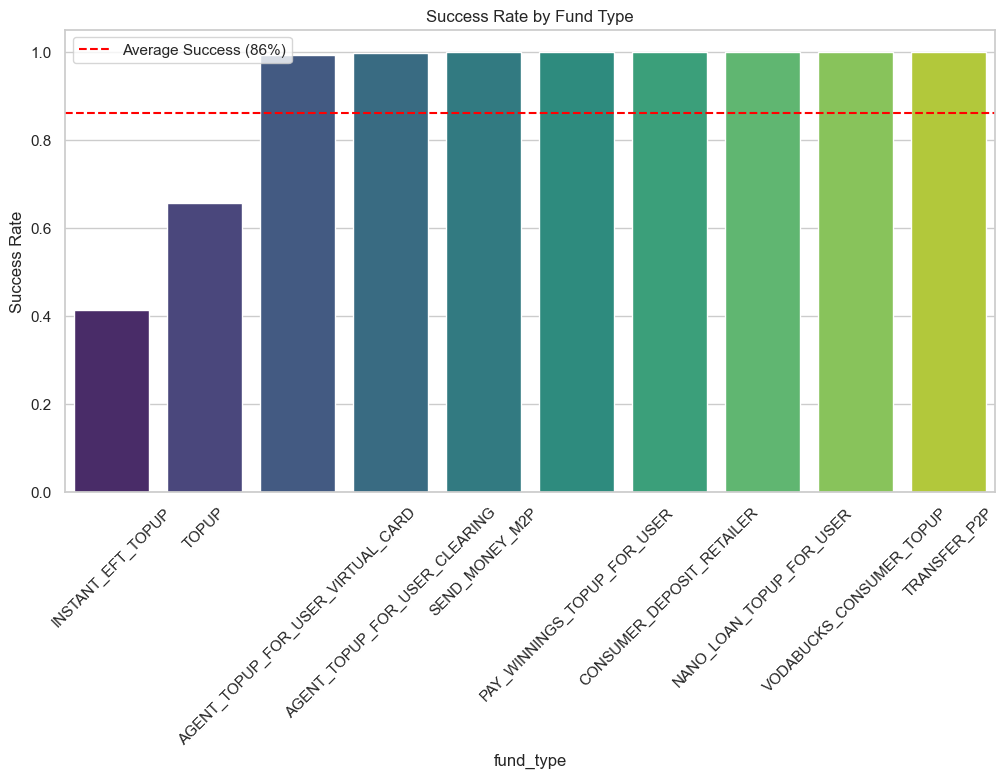

In [8]:
# --- 2.4 EXPLORATORY ANALYSIS ---

# 1. Group by fund_type and calculate the average of 'target'
# Since Target is 1 (Success) and 0 (Fail), the Mean = Success Rate!
risk_profile = df_clean.groupby('fund_type')['target'].agg(['count', 'mean']).sort_values(by='mean')

# Rename columns for clarity
risk_profile.columns = ['Total Orders', 'Success Rate']

print("📊 RISK PROFILE BY FUND TYPE")
print("(Sorted from Lowest Success Rate to Highest)")
display(risk_profile)

# 2. Visualize the results
plt.figure(figsize=(12, 6))
sns.barplot(x=risk_profile.index, y=risk_profile['Success Rate'], palette="viridis")
plt.axhline(0.86, color='red', linestyle='--', label='Average Success (86%)')
plt.title("Success Rate by Fund Type")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [9]:
# --- 2.5 MODEL PREPARATION ---

# 1. Feature Encoding (Turning text into numbers)
# We use get_dummies to create a column for each fund type
X = pd.get_dummies(df_clean[['fund_type', 'fund_amount']], drop_first=True)
y = df_clean['target']

# 2. The Train-Test Split
# We use the RANDOM_STATE and TEST_SIZE we set in our Config cell!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"✅ Data Split Complete!")
print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")

# 3. Quick Peek at the encoded features
display(X_train.head())

✅ Data Split Complete!
Training set: 1949244 rows
Testing set: 487311 rows


,fund_amount,fund_type_AGENT_TOPUP_FOR_USER_VIRTUAL_CARD,fund_type_CONSUMER_DEPOSIT_RETAILER,fund_type_INSTANT_EFT_TOPUP,fund_type_NANO_LOAN_TOPUP_FOR_USER,fund_type_PAY_WINNINGS_TOPUP_FOR_USER,fund_type_SEND_MONEY_M2P,fund_type_TOPUP,fund_type_TRANSFER_P2P,fund_type_VODABUCKS_CONSUMER_TOPUP
1935273,200,False,False,False,False,False,False,True,False,False
749023,8000,False,False,False,False,False,False,True,False,False
913060,500,False,False,False,False,False,False,False,False,True
2539405,1000,False,False,False,False,False,False,False,False,False
762274,2200,False,False,False,False,False,False,True,False,False


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# --- 1. LOGISTIC REGRESSION (The Baseline) ---
print("🚀 Training Logistic Regression...")
log_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)

# --- 2. RANDOM FOREST (The Powerhouse) ---
print("🌲 Training Random Forest (this may take a moment with 2M rows)...")
# We limit max_depth to 10 so it doesn't run forever for this prototype
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# --- 3. COMPARISON REPORT ---
print("\n" + "="*30)
print("🏆 FINAL PERFORMANCE COMPARISON")
print("="*30)

print(f"\n📊 LOGISTIC REGRESSION Accuracy: {accuracy_score(y_test, log_preds):.4f}")
print(classification_report(y_test, log_preds))

print(f"\n📊 RANDOM FOREST Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(classification_report(y_test, rf_preds))

# --- 4. THE "AXIOM" WINNER SELECTION ---
log_acc = accuracy_score(y_test, log_preds)
rf_acc = accuracy_score(y_test, rf_preds)

winner = "Random Forest" if rf_acc > log_acc else "Logistic Regression"
print(f"\n👑 PROTOTYPE WINNER: {winner}")

🚀 Training Logistic Regression...
🌲 Training Random Forest (this may take a moment with 2M rows)...

🏆 FINAL PERFORMANCE COMPARISON

📊 LOGISTIC REGRESSION Accuracy: 0.8922
              precision    recall  f1-score   support

           0       0.59      0.77      0.67     68463
           1       0.96      0.91      0.94    418848

    accuracy                           0.89    487311
   macro avg       0.77      0.84      0.80    487311
weighted avg       0.91      0.89      0.90    487311


📊 RANDOM FOREST Accuracy: 0.8956
              precision    recall  f1-score   support

           0       0.64      0.59      0.61     68463
           1       0.93      0.95      0.94    418848

    accuracy                           0.90    487311
   macro avg       0.79      0.77      0.78    487311
weighted avg       0.89      0.90      0.89    487311


👑 PROTOTYPE WINNER: Random Forest


In [11]:
import joblib

# --- 1. SAVE THE MODEL ---
model_filename = MODELS_DIR / "funding_model_rf.joblib"
joblib.dump(rf_model, model_filename)

# --- 2. SAVE THE FEATURE LIST ---
# We need to save the names of the columns so we know the order later
feature_filename = MODELS_DIR / "model_features.joblib"
joblib.dump(X.columns.tolist(), feature_filename)

print(f"💾 Model saved to: {model_filename}")
print(f"📝 Feature list saved to: {feature_filename}")

💾 Model saved to: /Users/ellenpeterson/Desktop/axiom_mlops_project/models/funding_model_rf.joblib
📝 Feature list saved to: /Users/ellenpeterson/Desktop/axiom_mlops_project/models/model_features.joblib


In [12]:
import pandas as pd
import joblib

# --- 1. LOAD THE TOOLS ---
# We load the model and the specific feature list we saved earlier
model = joblib.load(MODELS_DIR / "funding_model_rf.joblib")
model_features = joblib.load(MODELS_DIR / "model_features.joblib")

def predict_funding_success(fund_type, amount):
    """
    Takes a fund type and amount, and returns the model's prediction.
    """
    # Create a template dataframe with all zeros
    input_df = pd.DataFrame(0, index=[0], columns=model_features)
    
    # Set the amount
    input_df['fund_amount'] = amount
    
    # Find the correct column for this fund_type and set it to 1
    # Note: drop_first=True means the first category might not have a column
    target_col = f"fund_type_{fund_type}"
    if target_col in input_df.columns:
        input_df[target_col] = 1
    
    # Get Probability [Fail_Prob, Success_Prob]
    proba = model.predict_proba(input_df)[0]
    prediction = "✅ SUCCESS" if proba[1] > 0.5 else "❌ FAILED"
    
    print(f"--- 🔮 Axiom Prediction Report ---")
    print(f"Input: {fund_type} | Amount: {amount}")
    print(f"Result: {prediction}")
    print(f"Confidence: {proba[1]:.2%}")
    print("-" * 30)

# --- 2. RUN THE MOCK TESTS ---

# Test 1: The 'Risky' one we found in our Analysis
predict_funding_success("INSTANT_EFT_TOPUP", 500)

# Test 2: The 'Safe' one
predict_funding_success("TRANSFER_P2P", 500)

# Test 3: High Amount vs Low Amount on the same type
predict_funding_success("INSTANT_EFT_TOPUP", 100000)

--- 🔮 Axiom Prediction Report ---
Input: INSTANT_EFT_TOPUP | Amount: 500
Result: ❌ FAILED
Confidence: 35.40%
------------------------------
--- 🔮 Axiom Prediction Report ---
Input: TRANSFER_P2P | Amount: 500
Result: ✅ SUCCESS
Confidence: 99.95%
------------------------------
--- 🔮 Axiom Prediction Report ---
Input: INSTANT_EFT_TOPUP | Amount: 100000
Result: ❌ FAILED
Confidence: 26.98%
------------------------------
